In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
)
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import set_plot_sequential_data 

from flonacomldft.utils.diagnostics import R_hat

In [7]:
idxs = [32760170, 32760171, 32760172, 32760173, 32760750, 32760751] #3209454

# Load the data
PROJECT_PATH = get_project_path()
SIMULATIONS_DATA_PATH = PROJECT_PATH+"/5-multimodal-mlp"
CVS_DATA_PATH = PROJECT_PATH+"/cvs_temporal"

In [8]:
ab_flowmm_mlp = {}
cvs_mlp = {}

for i, idx in enumerate(idxs):
    print(idx, i)
    ab_flowmm_mlp[i] = load_pickle_file("results_multimodal_sampling_mixture_{:d}/checkpoint_NA_3000.pkl".format(
        idx), path=SIMULATIONS_DATA_PATH)
    cvs_mlp[i] = load_pickle_file("cvs_slices_{:d}_3000.pkl".format(
        idx), path=CVS_DATA_PATH)

32760170 0
32760171 1
32760172 2
32760173 3
32760750 4
32760751 5


In [9]:
labels_sims = {}

for i, j, k in zip(range(6), [5, 15, 30, 5, 15, 30], [1000, 1000, 1000, 1500, 1500, 1500]):
    labels_sims[i] = 'slice: {:d} mlp_init: {:d}'.format(j, k)

print(labels_sims)

{0: 'slice: 5 mlp_init: 1000', 1: 'slice: 15 mlp_init: 1000', 2: 'slice: 30 mlp_init: 1000', 3: 'slice: 5 mlp_init: 1500', 4: 'slice: 15 mlp_init: 1500', 5: 'slice: 30 mlp_init: 1500'}


# $\hat{R}$ calculations

In [10]:
us_cvs = {}

for i in range(6):
    us_cvs[i] = torch.cat((cvs_mlp[i], ab_flowmm_mlp[i]['us'].reshape(-1, 20, 1)), dim=2)

In [11]:
rhat = {}

for i in range(6):
    rhat[i] = R_hat(us_cvs[i].detach().numpy().transpose(1, 0, 2), labels=['C', 'R', 'U'])

In [12]:
time_mcmc = {}
for i in range(6):
    time_list = ab_flowmm_mlp[i]['time_mcmc']
    time_min = min(time_list)
    final_time = [t-time_min for t in time_list]
    time_mcmc[i]= np.array(final_time)/3600

In [13]:
time_mcmc

{0: array([0.00000000e+00, 7.07722690e-03, 1.17671095e-02, ...,
        2.47255142e+01, 2.47300749e+01, 2.47352986e+01]),
 1: array([0.00000000e+00, 5.74452625e-03, 1.38266543e-02, ...,
        2.54403102e+01, 2.54448946e+01, 2.54495231e+01]),
 2: array([0.00000000e+00, 6.17391891e-03, 1.31480293e-02, ...,
        2.56076002e+01, 2.56127669e+01, 2.56176437e+01]),
 3: array([0.00000000e+00, 5.15429298e-03, 1.00983137e-02, ...,
        2.40157326e+01, 2.40214258e+01, 2.40275191e+01]),
 4: array([0.00000000e+00, 4.80379032e-03, 9.18697483e-03, ...,
        2.22769509e+01, 2.22812960e+01, 2.22857792e+01]),
 5: array([0.00000000e+00, 5.87245491e-03, 1.15580397e-02, ...,
        3.17870987e+01, 3.17913226e+01, 3.17961784e+01])}

(array([[1.17949534, 1.18405241, 1.19789791],
       [1.25558025, 1.24023657, 1.37644252],
       [1.1771252 , 1.23490579, 1.28691164],
       [1.14543278, 1.1698103 , 1.28330074],
       [1.16578094, 1.12545281, 1.29037868],
       [1.15066571, 1.12104749, 1.27192675],
       [1.14605677, 1.13008663, 1.25973309],
       [1.14695589, 1.12911373, 1.23357078],
       [1.13822337, 1.12889099, 1.20864019],
       [1.13584973, 1.12872029, 1.2032488 ]]), array([ 290,  580,  870, 1160, 1450, 1740, 2030, 2320, 2610, 2901]), ['C', 'R', 'U'])
(array([[1.19982513, 1.25742187, 1.12577742],
       [1.11567158, 1.19157874, 1.12935833],
       [1.08097946, 1.12835993, 1.11365411],
       [1.08146942, 1.1282939 , 1.09724719],
       [1.06545637, 1.11150348, 1.11020279],
       [1.05052716, 1.0988806 , 1.09630864],
       [1.05711738, 1.08193173, 1.08304101],
       [1.05361865, 1.06313416, 1.06573962],
       [1.03976555, 1.05556269, 1.05512343],
       [1.03407236, 1.05234731, 1.05328645]]), array([ 

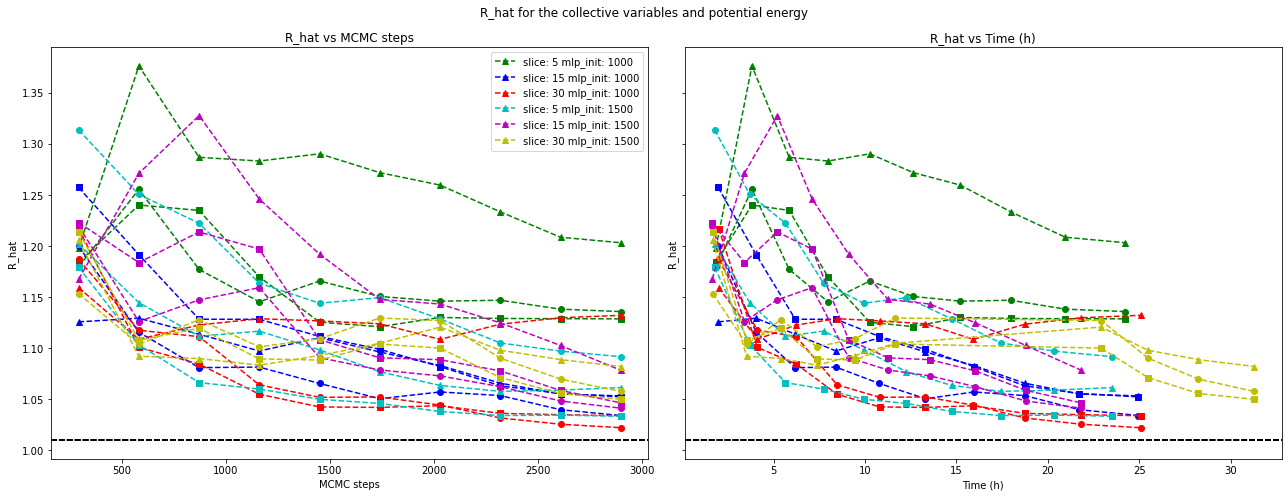

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
markers = ['o', 's', '^']
colors = ['g', 'b', 'r', 'c', 'm', 'y']

for i in range(6):
    print(rhat[i])
    for k in range(3):
        ax[0].plot( rhat[i][1], rhat[i][0][:, k], '--', marker=markers[k], color=colors[i], label="{:s}".format(labels_sims[i]))
        ax[1].plot( time_mcmc[i][rhat[i][1]], rhat[i][0][:, k], '--', marker=markers[k], color=colors[i], label="{:s}".format(labels_sims[i]))
 
    ax[0].axhline(1.01, color='k', linestyle='--')
    ax[0].set_xlabel("MCMC steps")
    ax[0].set_ylabel("R_hat")
    ax[0].set_title("R_hat vs MCMC steps")

    ax[1].axhline(1.01, color='k', linestyle='--')
    ax[1].set_xlabel("Time (h)")
    ax[1].set_ylabel("R_hat")
    ax[1].set_title("R_hat vs Time (h)")

handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[0].legend(by_label.values(), by_label.keys())

fig.suptitle("R_hat for the collective variables and potential energy")
plt.tight_layout()

# Plot acceptances

In [15]:
accs = {}

for i in range(6):
    accs[i] = ab_flowmm_mlp[i]['accs'].float().mean(dim=1)    

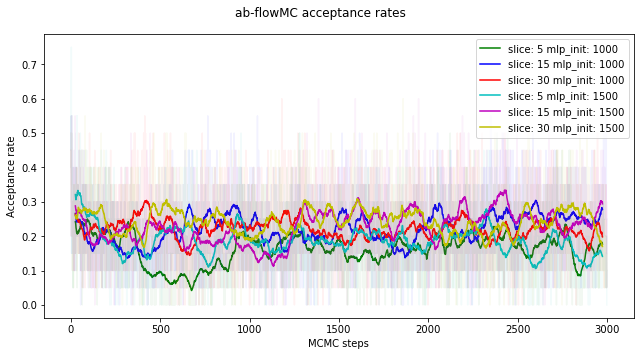

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5), sharey=True)

for i in range(6):
    set_plot_sequential_data(accs[i], ax=ax, color=colors[i], window_size=50, alpha=0.05, label="{:s}".format(labels_sims[i]))
    ax.set_xlabel("MCMC steps")
    ax.set_ylabel("Acceptance rate")
    ax.legend()
    #ax.set_title("Isomer {:d}".format(i))

fig.suptitle("ab-flowMC acceptance rates")
plt.tight_layout()

# Energy histograms

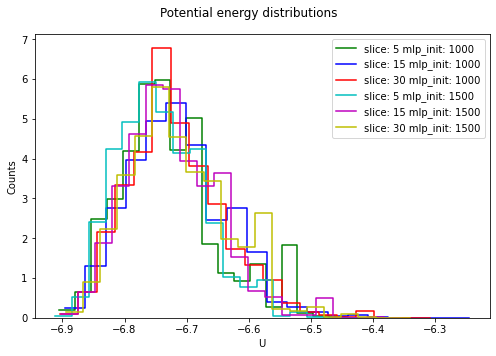

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for i in range(6):

    sns.histplot(us_cvs[i][:, :, 2].flatten(),
    bins=20,
    fill=False,
    color=colors[i],
    stat="density",
    element="step",
    ax=ax,
    label="{:s}".format(labels_sims[i]))
    j += 1

    ax.set_xlabel("U")
    ax.set_ylabel("Counts")
    ax.legend()

fig.suptitle("Potential energy distributions")
plt.tight_layout()

# Jumps between isomers

In [18]:
isomers = {}

for i in range(6):
    isomers[i] = ab_flowmm_mlp[i]['isomers']

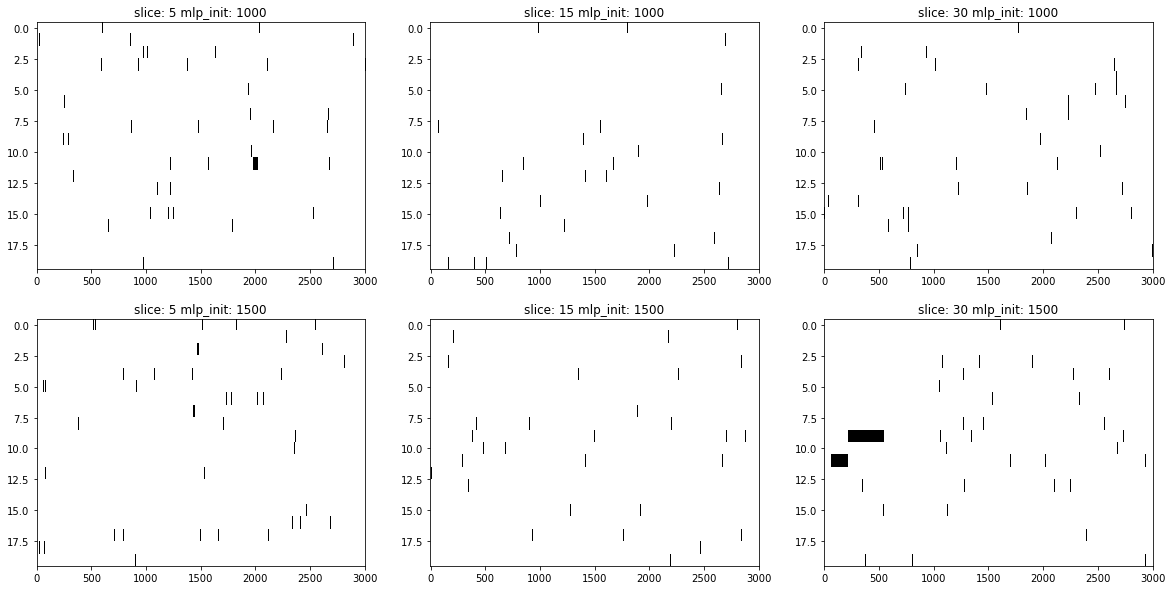

In [19]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

axs = axs.ravel()

for i in range(6):

    axs[i].imshow(isomers[i].T, aspect='auto', cmap='gray_r', interpolation='none')
    axs[i].set_title("{:s}".format(labels_sims[i]))

# Free energy

# MLP comparison with predictions